<a href="https://colab.research.google.com/github/andressonsino/football-data-analysis/blob/main/huracan/notebooks/san_lorenzo_huracan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

# Supresión de warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

# Configuración de visualización del DataFrame
pd.set_option('display.max_columns', None)   # muestra todas las columnas
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Configuración de gráficos
sns.set_theme(style='whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

In [2]:

# ── Configuración ──────────────────────────────────────────
DATA_PATH = r"../data/raw/san_lorenzo_huracan_raw.csv" # para jupyter
# DATA_PATH = r"/san_lorenzo_huracan_raw.csv"   # para colab
SEPARATOR = ","
ENCODING  = "utf-8"
# ───────────────────────────────────────────────────────────

df_raw = pd.read_csv(DATA_PATH, sep=SEPARATOR, encoding=ENCODING)
print(f"✅ Dataset cargado — Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}")


✅ Dataset cargado — Filas: 29 | Columnas: 24


# LIMPIEZA

In [3]:
# ─── Primeras y últimas filas ──────────────────────────────────────────────
print('\n--- Primeras 5 filas ---')
display(df_raw.head())

print('\n--- Últimas 5 filas ---')
display(df_raw.tail())

# ─── Dimensiones ───────────────────────────────────────────────────────────
print(f'Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')

# ─── Tipos de datos ────────────────────────────────────────────────────────
print('\n--- Info general ---')
df_raw.info()

# ─── Valores nulos por columna ─────────────────────────────────────────────
print('\n--- Nulos por columna ---')
# Verificamos si hay algún nulo en toda la tabla
if df_raw.isnull().sum().sum() == 0:
    print('✅ Sin valores nulos')
else:
    # Sino mostramos tabla filtrada de nulos
    nulos = pd.DataFrame({
        'Nulos': df_raw.isnull().sum(),
        'Porcentaje': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
    })
    display(nulos[nulos['Nulos'] > 0])

# ─── Duplicados ────────────────────────────────────────────────────────────
print(f'\nFilas duplicadas: {df_raw.duplicated().sum()}')

# ─── Estadísticas descriptivas ─────────────────────────────────────────────
print('\n--- Estadísticas descriptivas ---')
display(df_raw.describe())


--- Primeras 5 filas ---


,Player,#,Nation,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG,PKwon,PKcon,-9999
0,Rodrigo Auzmendi,29,ar ARG,FW,25-219,90,0,0,0,0,5,1,1,0,2,2,2,0,0,0,0,NaN,NaN,c89d0b23
1,Alexis Cuello,9,ar ARG,FW,26-172,90,0,0,0,0,1,0,0,0,1,3,0,2,1,0,0,NaN,NaN,0bf6b89a
2,Nicolás Tripichio,24,ar ARG,CM,30-216,90,0,0,0,0,1,0,0,0,3,2,0,1,1,2,0,NaN,NaN,4c3e3d0a
3,Martín Río,27,ar ARG,CM,25-148,52,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,NaN,NaN,5b3a9431
4,Juan Rattalino,13,ar ARG,MF,22-198,38,0,0,0,0,0,0,0,0,0,1,0,3,0,0,0,NaN,NaN,98dc6e33



--- Últimas 5 filas ---


,Player,#,Nation,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG,PKwon,PKcon,-9999
24,Máximo Palazzo,35,ar ARG,LB,21-064,90,0,0,0,0,0,0,0,0,3,0,0,4,3,0,0,NaN,NaN,90b5bc97
25,Lucas Carrizo,3,ar ARG,CB,29-081,90,0,0,0,0,0,0,1,0,2,2,0,0,2,0,0,NaN,NaN,2bfc68c3
26,Hugo Nervo,21,ar ARG,CB,35-215,90,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,NaN,NaN,6afd25e6
27,Lucas Blondel,2,ch SUI,RB,29-329,90,0,0,0,0,3,1,0,0,2,1,0,1,0,1,0,NaN,NaN,4b97076c
28,Hernán Galíndez,1,ec ECU,GK,39-132,90,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,89c136f6


Filas: 29 | Columnas: 24

--- Info general ---
<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  29 non-null     str    
 1   #       29 non-null     int64  
 2   Nation  29 non-null     str    
 3   Pos     29 non-null     str    
 4   Age     29 non-null     str    
 5   Min     29 non-null     int64  
 6   Gls     29 non-null     int64  
 7   Ast     29 non-null     int64  
 8   PK      29 non-null     int64  
 9   PKatt   29 non-null     int64  
 10  Sh      29 non-null     int64  
 11  SoT     29 non-null     int64  
 12  CrdY    29 non-null     int64  
 13  CrdR    29 non-null     int64  
 14  Fls     29 non-null     int64  
 15  Fld     29 non-null     int64  
 16  Off     29 non-null     int64  
 17  Crs     29 non-null     int64  
 18  TklW    29 non-null     int64  
 19  Int     29 non-null     int64  
 20  OG      29 non-null     int64  
 21  PKwon

,Nulos,Porcentaje
PKwon,29,100.00
PKcon,29,100.00



Filas duplicadas: 0

--- Estadísticas descriptivas ---


,#,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG,PKwon,PKcon
count,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,29.00,0.00,0.00
mean,17.07,67.28,0.07,0.03,0.00,0.00,0.76,0.24,0.21,0.03,1.07,1.07,0.10,1.28,1.24,0.59,0.00,NaN,NaN
std,13.20,27.85,0.37,0.19,0.00,0.00,1.55,0.58,0.41,0.19,1.25,1.22,0.41,1.85,1.15,1.30,0.00,NaN,NaN
min,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
25%,7.00,45.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
50%,13.00,89.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,0.00,0.00,NaN,NaN
75%,24.00,90.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,2.00,2.00,0.00,1.00,2.00,0.00,0.00,NaN,NaN
max,54.00,90.00,2.00,1.00,0.00,0.00,6.00,2.00,1.00,1.00,5.00,4.00,2.00,7.00,4.00,5.00,0.00,NaN,NaN


In [4]:
#── Eliminar columna entera ────────────────────────────────────────────────
# Cuándo: más del 50% de nulos y la columna no aporta valor
df_raw = df_raw.drop(columns=['PKwon', 'PKcon', '-9999'])

In [5]:
# Nos quedamos solo con los últimos 3 caracteres de cada fila en la columna 'Nation'
df_raw['Nation'] = df_raw['Nation'].str[-3:]

In [6]:
df_raw

,Player,#,Nation,Pos,Age,Min,Gls,Ast,PK,PKatt,Sh,SoT,CrdY,CrdR,Fls,Fld,Off,Crs,TklW,Int,OG
0,Rodrigo Auzmendi,29,ARG,FW,25-219,90,0,0,0,0,5,1,1,0,2,2,2,0,0,0,0
1,Alexis Cuello,9,ARG,FW,26-172,90,0,0,0,0,1,0,0,0,1,3,0,2,1,0,0
2,Nicolás Tripichio,24,ARG,CM,30-216,90,0,0,0,0,1,0,0,0,3,2,0,1,1,2,0
3,Martín Río,27,ARG,CM,25-148,52,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0
4,Juan Rattalino,13,ARG,MF,22-198,38,0,0,0,0,0,0,0,0,0,1,0,3,0,0,0
5,Facundo Gulli,10,ARG,CM,20-318,52,0,0,0,0,0,0,0,0,0,3,0,4,1,0,0
6,Gustavo Del Prete,21,ARG,FWMF,30-058,38,0,0,0,0,0,0,0,0,0,4,0,1,1,0,0
7,Mathías De Ritis,6,URU,LB,23-190,45,0,0,0,0,0,0,1,0,1,2,0,1,2,1,0
8,Teo Rodríguez,3,ARG,DF,20-301,45,0,0,0,0,1,1,0,0,1,0,0,6,1,0,0
9,Alejo Córdoba,35,ARG,CB,22-094,90,0,0,0,0,0,0,0,0,0,1,0,1,3,5,0


In [8]:
# --- Separar en dos columnas usando regex con grupos -----------------------

#df_raw['edad_anios'] = df_raw['Age'].str.extract(r'^(\d+)')          # Extrae los números antes del guion
#df_raw['edad_dias'] = df_raw['Age'].str.extract(r'-(\d+)').astype(float)  # Extrae los números después del guion

# ── Verificar ────────────────────────────────────────────────────────────
print(f"NaN en edad_años: {df_raw['edad_anios'].isnull().sum()}")
print(f"NaN en edad_dias: {df_raw['edad_dias'].isnull().sum()}")
display(df_raw[['edad_anios', 'edad_dias']].head(5))

# ── Eliminar columna original una vez verificado ─────────────────────────
#df_raw = df_raw.drop(columns=['Age'])

NaN en edad_años: 0
NaN en edad_dias: 0


,edad_anios,edad_dias
0,25,219.00
1,26,172.00
2,30,216.00
3,25,148.00
4,22,198.00


In [9]:
# Detectar con IQR
def detectar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]
    print(f'{columna}:')
    print(f'  Rango normal: [{lim_inf:.2f}, {lim_sup:.2f}]')
    print(f'  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)\n')

# 1. Filtramos para agarrar solo las columnas que tienen números (ignoramos textos/nombres)
columnas_numericas = df_raw.select_dtypes(include=['number']).columns

# 2. Hacemos que Python pase la función por cada una de esas columnas automáticamente
for col in columnas_numericas:
    detectar_outliers(df_raw, col)
    print("-" * 40) # Imprime una línea separadora para que se lea mejor

#:
  Rango normal: [-18.50, 49.50]
  Outliers: 1 (3.4%)

----------------------------------------
Min:
  Rango normal: [-22.50, 157.50]
  Outliers: 0 (0.0%)

----------------------------------------
Gls:
  Rango normal: [0.00, 0.00]
  Outliers: 1 (3.4%)

----------------------------------------
Ast:
  Rango normal: [0.00, 0.00]
  Outliers: 1 (3.4%)

----------------------------------------
PK:
  Rango normal: [0.00, 0.00]
  Outliers: 0 (0.0%)

----------------------------------------
PKatt:
  Rango normal: [0.00, 0.00]
  Outliers: 0 (0.0%)

----------------------------------------
Sh:
  Rango normal: [-1.50, 2.50]
  Outliers: 4 (13.8%)

----------------------------------------
SoT:
  Rango normal: [0.00, 0.00]
  Outliers: 5 (17.2%)

----------------------------------------
CrdY:
  Rango normal: [0.00, 0.00]
  Outliers: 6 (20.7%)

----------------------------------------
CrdR:
  Rango normal: [0.00, 0.00]
  Outliers: 1 (3.4%)

----------------------------------------
Fls:
  Rango normal

In [10]:
# Tipos de datos finales
print(df_raw.dtypes)

Player            str
#               int64
Nation            str
Pos               str
Min             int64
Gls             int64
Ast             int64
PK              int64
PKatt           int64
Sh              int64
SoT             int64
CrdY            int64
CrdR            int64
Fls             int64
Fld             int64
Off             int64
Crs             int64
TklW            int64
Int             int64
OG              int64
edad_anios        str
edad_dias     float64
dtype: object


In [11]:
# Convierto el tipo de dato edad_dias a int64
df_raw['edad_dias'] = df_raw['edad_dias'].astype(int)

In [12]:
# Creamos la columna principal agarrando solo las dos primeras letras de la original
df_raw['Pos_Principal'] = df_raw['Pos'].str[:2]

In [13]:
# Le decimos a Pandas: "Buscá a la fila donde el Player sea 'Óscar Romero',
# y en su columna 'Pos_Principal', forzá el valor a 'MF'"
df_raw.loc[df_raw['Player'] == 'Óscar Romero', 'Pos_Principal'] = 'MF'

In [18]:
# ── Diccionarios de traducción FBref ─────────────────────────────────────
# Reutilizable en cualquier análisis de FBref
# Fuente: glosario oficial FBref

COLUMNAS_ES = {
    'Player':        'Jugador',
    '#':             'Camiseta',
    'Pos':           'Posición',
    'Pos_Principal': 'Posición principal',
    'Age':           'Edad',
    'Min':           'Minutos',
    'Gls':           'Goles',
    'Ast':           'Asistencias',
    'PK':            'Penales convertidos',
    'PKatt':         'Penales intentados',
    'Sh':            'Tiros totales',
    'SoT':           'Tiros al arco',
    'CrdY':          'Tarjetas amarillas',
    'CrdR':          'Tarjetas rojas',
    'Fls':           'Faltas cometidas',
    'Fld':           'Faltas recibidas',
    'Off':           'Fueras de juego',
    'Crs':           'Centros',
    'TklW':          'Entradas ganadas',
    'Int':           'Intercepciones',
    'OG':            'Goles en contra',
    'PKwon':         'Penales ganados',
    'PKcon':         'Penales concedidos',
    'edad_anios':  'Edad (años)',
    'edad_dias':  'Edad (días de año en curso)'
}

POSICIONES_ES = {
    'GK':   'Arquero',
    'DF':   'Defensor',
    'MF':   'Mediocampista',
    'FW':   'Delantero',
    'FB':   'Lateral',
    'LB':   'Lateral izquierdo',
    'RB':   'Lateral derecho',
    'CB':   'Defensor central',
    'DM':   'Mediocampista defensivo',
    'CM':   'Mediocampista central',
    'LM':   'Mediocampista izquierdo',
    'RM':   'Mediocampista derecho',
    'WM':   'Mediocampista amplio',
    'LW':   'Extremo izquierdo',
    'RW':   'Extremo derecho',
    'AM':   'Mediocampista ofensivo',
    'FWMF': 'Delantero/Mediocampista',
    'MFFW': 'Mediocampista/Delantero',
    'DFMF': 'Defensor/Mediocampista',
    'MFDF': 'Mediocampista/Defensor'
}


def traducir_columnas(df):
    """
    Renombra las columnas de un DataFrame de FBref al español.
    Solo traduce las columnas que existen — no falla si faltan columnas.
    """
    columnas_presentes = {k: v for k, v in COLUMNAS_ES.items() if k in df.columns}
    df = df.rename(columns=columnas_presentes)
    print(f"Columnas traducidas: {len(columnas_presentes)}")
    return df


def traducir_posiciones(df, columna='Posición'):
    """
    Traduce las abreviaturas de posición al español.
    Maneja posiciones combinadas como 'DF,FW' o 'FW,MF'.

    Parámetros:
        columna : nombre de la columna de posición (después de traducir columnas)
    """
    if columna not in df.columns:
        print(f"Columna '{columna}' no encontrada — verificá que ya tradujiste las columnas")
        return df

    def traducir_pos(valor):
        if pd.isna(valor):
            return valor
        # Manejar posiciones combinadas (ej: 'DF,FW', 'FW,MF')
        partes = str(valor).split(',')
        traducidas = [POSICIONES_ES.get(p.strip(), p.strip()) for p in partes]
        return ' / '.join(traducidas)

    df[columna] = df[columna].apply(traducir_pos)
    return df


#── Uso ───────────────────────────────────────────────────────────────────
df_raw = traducir_columnas(df_raw)
# Traducimos la columna original (Para mantener el detalle híbrido)
df_raw = traducir_posiciones(df_raw, columna='Posición')
# Traducimos la nueva columna (Para tener la versión simplificada a 2 letras)
df_raw = traducir_posiciones(df_raw, columna='Posición principal')

display(df_raw.head())

Columnas traducidas: 2


,Jugador,Camiseta,Nation,Posición,Minutos,Goles,Asistencias,Penales convertidos,Penales intentados,Tiros totales,Tiros al arco,Tarjetas amarillas,Tarjetas rojas,Faltas cometidas,Faltas recibidas,Fueras de juego,Centros,Entradas ganadas,Intercepciones,Goles en contra,Edad (años),Edad (días de año en curso),Posición principal
0,Rodrigo Auzmendi,29,ARG,Delantero,90,0,0,0,0,5,1,1,0,2,2,2,0,0,0,0,25,219,Delantero
1,Alexis Cuello,9,ARG,Delantero,90,0,0,0,0,1,0,0,0,1,3,0,2,1,0,0,26,172,Delantero
2,Nicolás Tripichio,24,ARG,Mediocampista central,90,0,0,0,0,1,0,0,0,3,2,0,1,1,2,0,30,216,Mediocampista central
3,Martín Río,27,ARG,Mediocampista central,52,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,25,148,Mediocampista central
4,Juan Rattalino,13,ARG,Mediocampista,38,0,0,0,0,0,0,0,0,0,1,0,3,0,0,0,22,198,Mediocampista


In [19]:
df_raw

,Jugador,Camiseta,Nation,Posición,Minutos,Goles,Asistencias,Penales convertidos,Penales intentados,Tiros totales,Tiros al arco,Tarjetas amarillas,Tarjetas rojas,Faltas cometidas,Faltas recibidas,Fueras de juego,Centros,Entradas ganadas,Intercepciones,Goles en contra,Edad (años),Edad (días de año en curso),Posición principal
0,Rodrigo Auzmendi,29,ARG,Delantero,90,0,0,0,0,5,1,1,0,2,2,2,0,0,0,0,25,219,Delantero
1,Alexis Cuello,9,ARG,Delantero,90,0,0,0,0,1,0,0,0,1,3,0,2,1,0,0,26,172,Delantero
2,Nicolás Tripichio,24,ARG,Mediocampista central,90,0,0,0,0,1,0,0,0,3,2,0,1,1,2,0,30,216,Mediocampista central
3,Martín Río,27,ARG,Mediocampista central,52,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,25,148,Mediocampista central
4,Juan Rattalino,13,ARG,Mediocampista,38,0,0,0,0,0,0,0,0,0,1,0,3,0,0,0,22,198,Mediocampista
5,Facundo Gulli,10,ARG,Mediocampista central,52,0,0,0,0,0,0,0,0,0,3,0,4,1,0,0,20,318,Mediocampista central
6,Gustavo Del Prete,21,ARG,Delantero/Mediocampista,38,0,0,0,0,0,0,0,0,0,4,0,1,1,0,0,30,58,Delantero
7,Mathías De Ritis,6,URU,Lateral izquierdo,45,0,0,0,0,0,0,1,0,1,2,0,1,2,1,0,23,190,Lateral izquierdo
8,Teo Rodríguez,3,ARG,Defensor,45,0,0,0,0,1,1,0,0,1,0,0,6,1,0,0,20,301,Defensor
9,Alejo Córdoba,35,ARG,Defensor central,90,0,0,0,0,0,0,0,0,0,1,0,1,3,5,0,22,94,Defensor central


In [20]:
# Ver si el índice tiene huecos
print(f'Índice antes del reset: {df_raw.index.tolist()[:10]}...')

# Resetear
df_raw = df_raw.reset_index(drop=True)

# Verificar
print(f'Índice después del reset: {df_raw.index.tolist()[:10]}...')
print(f'Filas finales: {df_raw.shape[0]}')

Índice antes del reset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Índice después del reset: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]...
Filas finales: 29


In [21]:
print('=' * 50)
print('REPORTE FINAL DE CALIDAD')
print('=' * 50)
print(f'Filas finales:      {df_raw.shape[0]}')
print(f'Columnas:           {df_raw.shape[1]}')
print(f'Duplicados:         {df_raw.duplicated().sum()}')
print(f'Nulos totales:      {df_raw.isnull().sum().sum()}')
print('=' * 50)

REPORTE FINAL DE CALIDAD
Filas finales:      29
Columnas:           23
Duplicados:         0
Nulos totales:      0


In [23]:
# COLAB
# Renombrar a df_clean antes de exportar
#df_clean = df_raw.copy()

# Exportar
#nombre_salida = 'san_lorenzo_huracan_clean.csv'
#df_clean.to_csv(nombre_salida, index=False, encoding='utf-8')
#print(f'Dataset exportado: {nombre_salida}')
#print(f'Filas: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}')

# Renombrar a df_clean antes de exportar
df_clean = df_raw.copy()

# Exportar
nombre_salida = '../data/clean/san_lorenzo_huracan_clean.csv'    
df_clean.to_csv(nombre_salida, index=False, encoding='utf-8')
print(f'Dataset exportado: {nombre_salida}')
print(f'Filas: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}')

Dataset exportado: ../data/clean/san_lorenzo_huracan_clean.csv
Filas: 29 | Columnas: 23


# EDA

In [24]:
# Diagnóstico estructural

# Tipos de datos y nulos
df_clean.info()
# Estadísticas descriptivas de variables numéricas
df_clean.describe()
# Primeras filas
df_clean.head()
# Nulos y porcentaje
nulos = pd.DataFrame({
    'Nulos': df_clean.isnull().sum(),
    'Porcentaje': (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})
display(nulos[nulos['Nulos'] > 0])
# Duplicados
print(f'Filas duplicadas: {df_clean.duplicated().sum()}')
# Valores únicos por columna
df_clean.nunique().sort_values()


<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Jugador                      29 non-null     str  
 1   Camiseta                     29 non-null     int64
 2   Nation                       29 non-null     str  
 3   Posición                     29 non-null     str  
 4   Minutos                      29 non-null     int64
 5   Goles                        29 non-null     int64
 6   Asistencias                  29 non-null     int64
 7   Penales convertidos          29 non-null     int64
 8   Penales intentados           29 non-null     int64
 9   Tiros totales                29 non-null     int64
 10  Tiros al arco                29 non-null     int64
 11  Tarjetas amarillas           29 non-null     int64
 12  Tarjetas rojas               29 non-null     int64
 13  Faltas cometidas             29 non-null     int64
 14  Faltas 

,Nulos,Porcentaje


Filas duplicadas: 0


Penales convertidos             1
Penales intentados              1
Goles en contra                 1
Asistencias                     2
Tarjetas amarillas              2
Tarjetas rojas                  2
Goles                           2
Tiros al arco                   3
Fueras de juego                 3
Faltas cometidas                5
Faltas recibidas                5
Tiros totales                   5
Entradas ganadas                5
Intercepciones                  6
Centros                         7
Nation                          7
Posición principal              8
Posición                        9
Minutos                        13
Edad (años)                    15
Camiseta                       22
Edad (días de año en curso)    28
Jugador                        29
dtype: int64

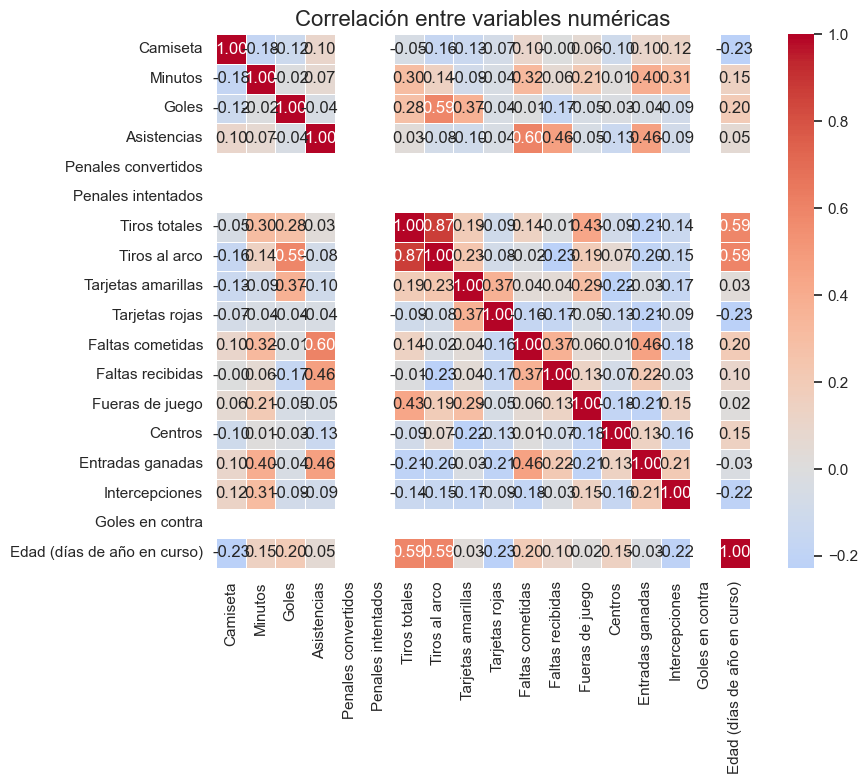

In [29]:
plt.figure(figsize=(10, 8))
correlacion = df_clean[columnas_numericas].corr()

sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
)
plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.grid(False)
plt.show()

In [32]:
# Configuración del partido
EQUIPO_LOCAL    = 'San Lorenzo'       
EQUIPO_VISITANTE = 'Huracán'     
TEMPORADA       = '2026'         

Jugadores con minutos jugados: 29


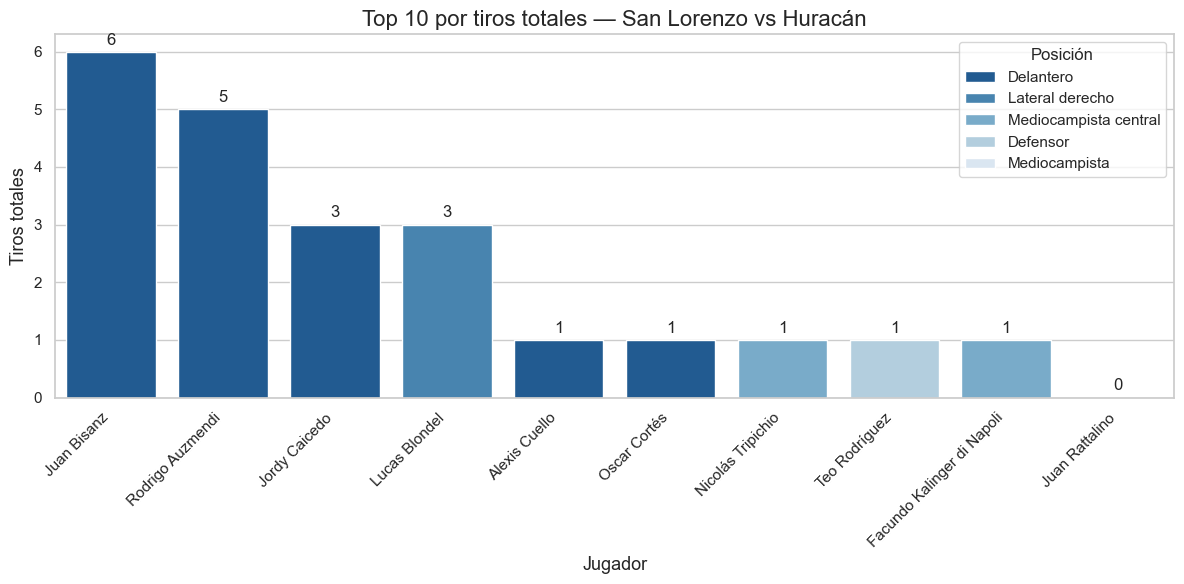

In [33]:
# Top jugadores por tiros totales
# Filtrar solo jugadores que participaron (más de 0 minutos)
df_activos = df_clean[df_clean['Minutos'] > 0].copy()
print(f'Jugadores con minutos jugados: {len(df_activos)}')
df_ofensivo = df_activos[['Jugador', 'Posición', 'Minutos',
                            'Tiros totales', 'Tiros al arco',
                            'Goles', 'Asistencias']].copy()

df_ofensivo = df_ofensivo.sort_values('Tiros totales', ascending=False)

plt.figure(figsize=(12, 6))
p = sns.barplot(
    data=df_ofensivo.head(10),
    x='Jugador',
    y='Tiros totales',
    hue='Posición',
    dodge=False,
    palette='Blues_r'
)
for container in p.containers:
    p.bar_label(container, label_type='edge', padding=3)
plt.title(f'Top 10 por tiros totales — {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/top_tiros.png', dpi=150, bbox_inches='tight')
plt.show()

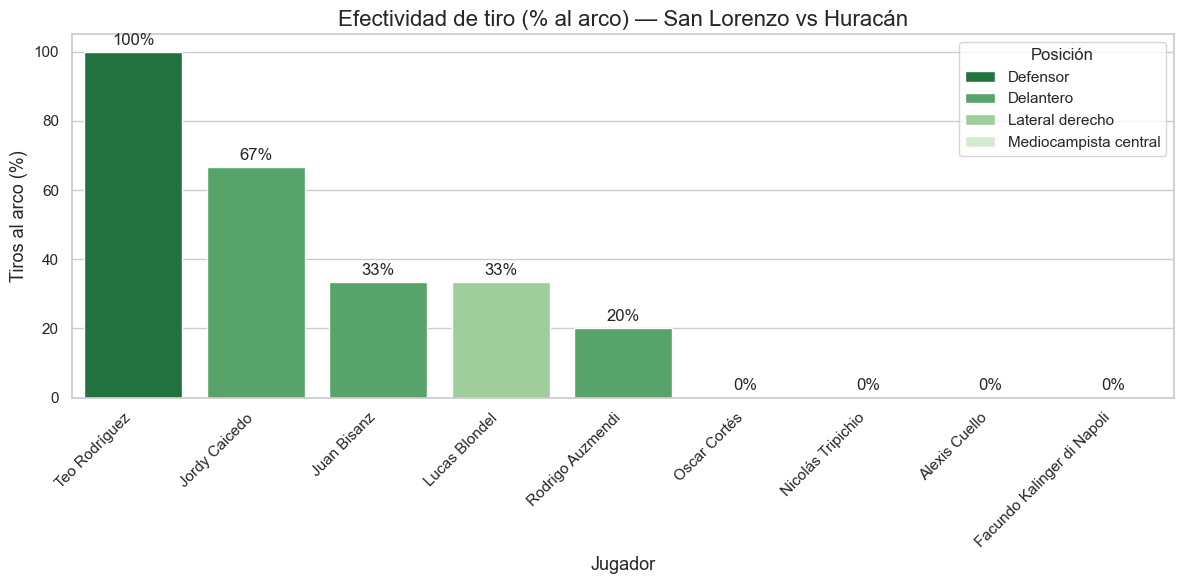

In [34]:
# Efectividad: tiros al arco sobre tiros totales
# Solo jugadores con al menos 1 tiro
df_tiros = df_activos[df_activos['Tiros totales'] > 0].copy()
df_tiros['efectividad_tiro'] = (
    df_tiros['Tiros al arco'] / df_tiros['Tiros totales'] * 100
).round(1)

df_tiros = df_tiros.sort_values('efectividad_tiro', ascending=False)

plt.figure(figsize=(12, 6))
p = sns.barplot(
    data=df_tiros,
    x='Jugador',
    y='efectividad_tiro',
    hue='Posición',
    dodge=False,
    palette='Greens_r'
)
for container in p.containers:
    p.bar_label(container, fmt='%.0f%%', label_type='edge', padding=3)
plt.title(f'Efectividad de tiro (% al arco) — {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE}')
plt.ylabel('Tiros al arco (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/efectividad_tiro.png', dpi=150, bbox_inches='tight')
plt.show()

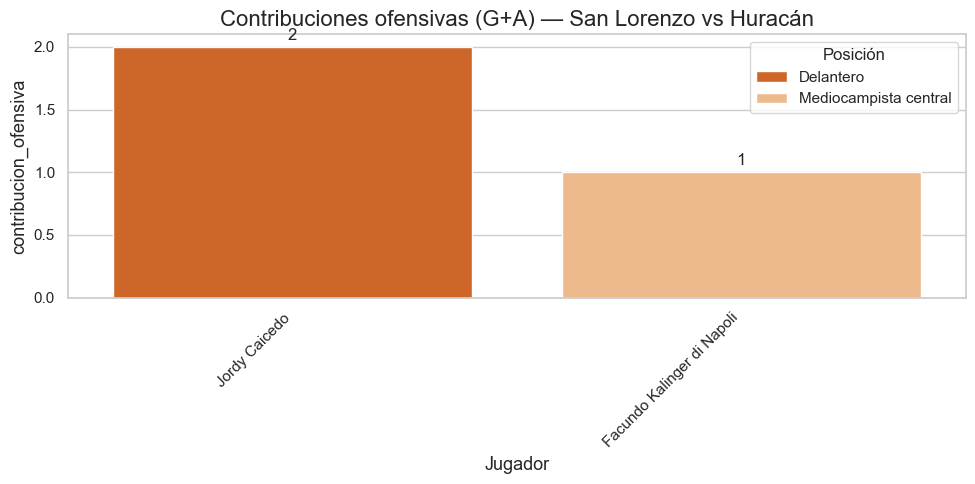

In [35]:
# Contribuciones directas: goles + asistencias
df_activos['contribucion_ofensiva'] = df_activos['Goles'] + df_activos['Asistencias']
df_contrib = df_activos[df_activos['contribucion_ofensiva'] > 0].sort_values(
    'contribucion_ofensiva', ascending=False
)

if len(df_contrib) == 0:
    print("Sin goles ni asistencias en este partido")
else:
    plt.figure(figsize=(10, 5))
    p = sns.barplot(
        data=df_contrib,
        x='Jugador',
        y='contribucion_ofensiva',
        hue='Posición',
        dodge=False,
        palette='Oranges_r'
    )
    for container in p.containers:
        p.bar_label(container, label_type='edge', padding=3)
    plt.title(f'Contribuciones ofensivas (G+A) — {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../outputs/contribucion_ofensiva.png', dpi=150, bbox_inches='tight')
    plt.show()

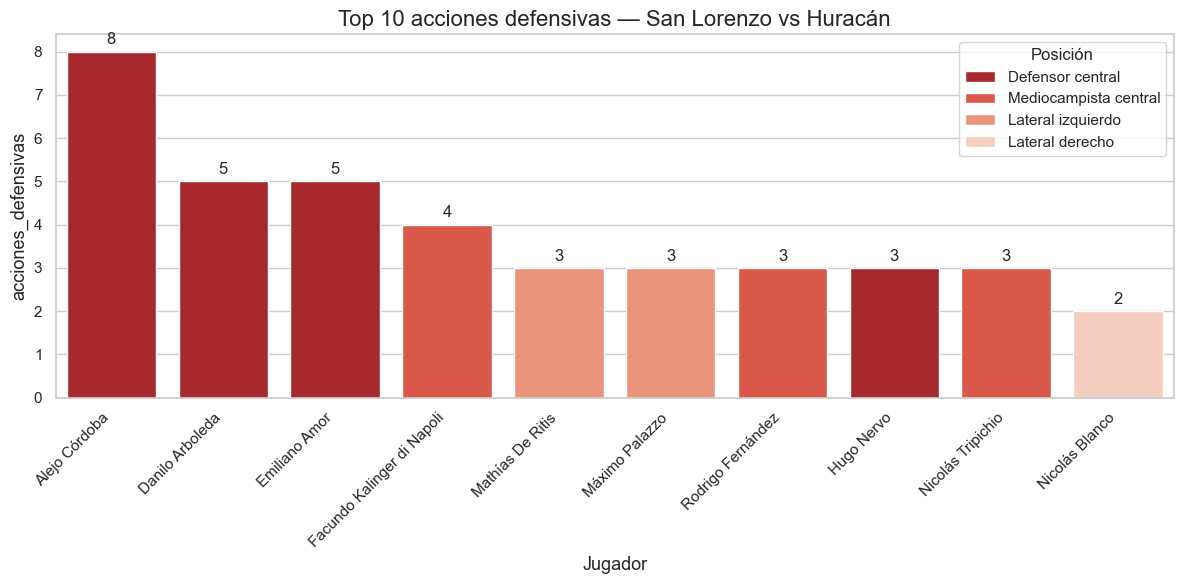

In [36]:
# Acciones defensivas: entradas ganadas + intercepciones
df_activos['acciones_defensivas'] = (
    df_activos['Entradas ganadas'] + df_activos['Intercepciones']
)

df_def = df_activos[['Jugador', 'Posición', 'Minutos',
                       'Entradas ganadas', 'Intercepciones',
                       'acciones_defensivas']].sort_values(
    'acciones_defensivas', ascending=False
)

plt.figure(figsize=(12, 6))
p = sns.barplot(
    data=df_def.head(10),
    x='Jugador',
    y='acciones_defensivas',
    hue='Posición',
    dodge=False,
    palette='Reds_r'
)
for container in p.containers:
    p.bar_label(container, label_type='edge', padding=3)
plt.title(f'Top 10 acciones defensivas — {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/acciones_defensivas.png', dpi=150, bbox_inches='tight')
plt.show()

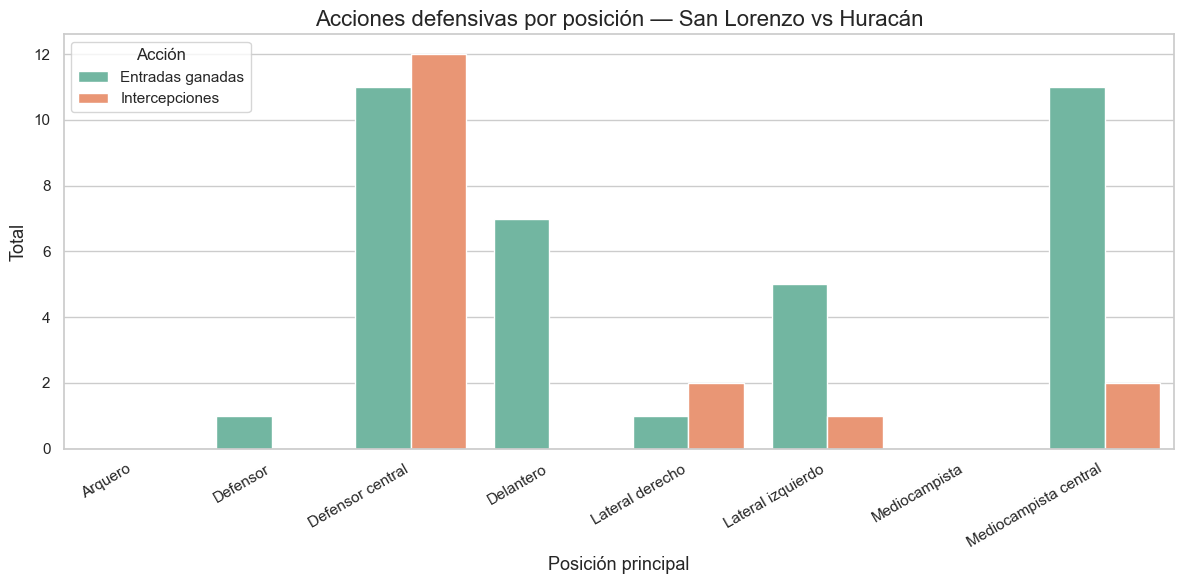

In [38]:
df_def_pos = df_activos.groupby('Posición principal')[
    ['Entradas ganadas', 'Intercepciones']
].sum().reset_index()

df_def_pos_melt = df_def_pos.melt(
    id_vars='Posición principal',
    value_vars=['Entradas ganadas', 'Intercepciones'],
    var_name='Acción',
    value_name='Total'
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_def_pos_melt,
    x='Posición principal',
    y='Total',
    hue='Acción',
    palette='Set2'
)
plt.title(f'Acciones defensivas por posición — {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE}')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/defensiva_por_posicion.png', dpi=150, bbox_inches='tight')
plt.show()

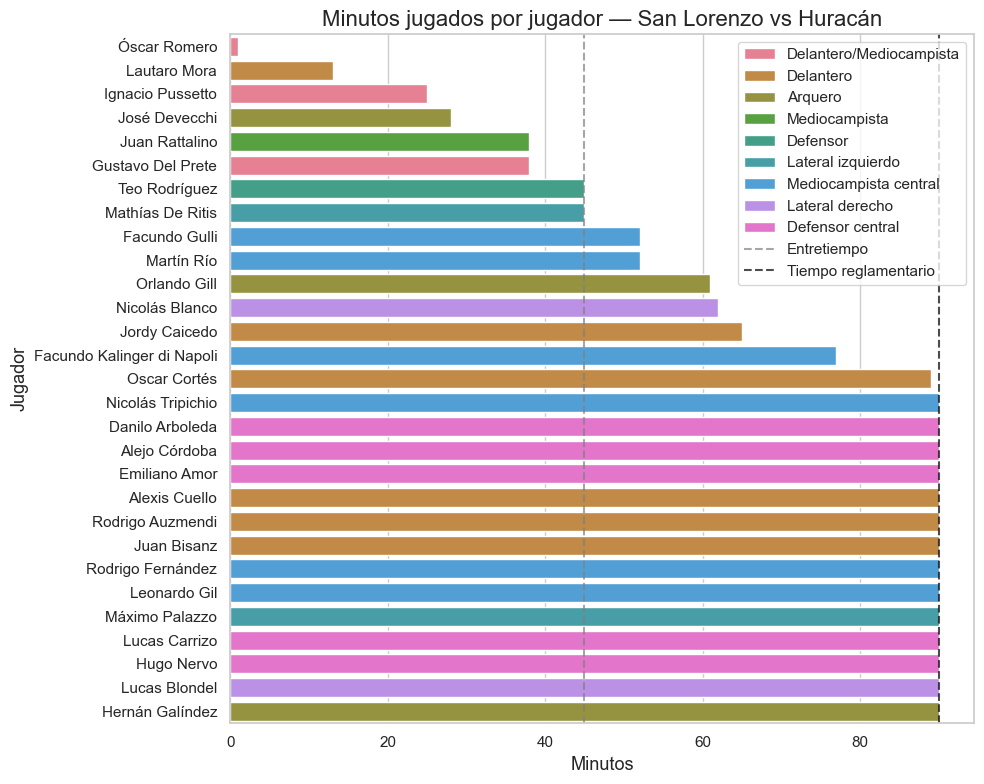

In [39]:
df_min = df_activos.sort_values('Minutos', ascending=True)

plt.figure(figsize=(10, 8))
p = sns.barplot(
    data=df_min,
    x='Minutos',
    y='Jugador',
    hue='Posición',
    dodge=False,
    palette='husl'
)
plt.axvline(45, color='gray', linestyle='--', alpha=0.7, label='Entretiempo')
plt.axvline(90, color='black', linestyle='--', alpha=0.7, label='Tiempo reglamentario')
plt.title(f'Minutos jugados por jugador — {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE}')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/minutos_jugados.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# Normalizar acciones por 90 minutos para comparar titulares y suplentes
df_activos = df_activos[df_activos['Minutos'] >= 10].copy()  # mínimo 10 min

df_activos['tiros_per90']    = df_activos['Tiros totales'] / df_activos['Minutos'] * 90
df_activos['def_per90']      = df_activos['acciones_defensivas'] / df_activos['Minutos'] * 90
df_activos['centros_per90']  = df_activos['Centros'] / df_activos['Minutos'] * 90

print("Métricas per90 calculadas")
display(df_activos[['Jugador', 'Posición', 'Minutos',
                     'tiros_per90', 'def_per90', 'centros_per90']].sort_values(
    'tiros_per90', ascending=False
))

Métricas per90 calculadas


,Jugador,Posición,Minutos,tiros_per90,def_per90,centros_per90
19,Juan Bisanz,Delantero,90,6.00,1.00,1.00
0,Rodrigo Auzmendi,Delantero,90,5.00,0.00,0.00
17,Jordy Caicedo,Delantero,65,4.15,1.38,1.38
27,Lucas Blondel,Lateral derecho,90,3.00,1.00,1.00
8,Teo Rodríguez,Defensor,45,2.00,2.00,12.00
22,Facundo Kalinger di Napoli,Mediocampista central,77,1.17,4.68,0.00
15,Oscar Cortés,Delantero,89,1.01,1.01,0.00
2,Nicolás Tripichio,Mediocampista central,90,1.00,3.00,1.00
1,Alexis Cuello,Delantero,90,1.00,1.00,2.00
3,Martín Río,Mediocampista central,52,0.00,0.00,0.00


In [41]:
# Resumen de métricas clave agrupadas por posición
metricas_por_pos = df_activos.groupby('Posición').agg(
    jugadores=('Jugador', 'count'),
    minutos_prom=('Minutos', 'mean'),
    tiros_total=('Tiros totales', 'sum'),
    tiros_arco_total=('Tiros al arco', 'sum'),
    goles_total=('Goles', 'sum'),
    def_total=('acciones_defensivas', 'sum'),
    faltas_com=('Faltas cometidas', 'sum'),
    faltas_rec=('Faltas recibidas', 'sum'),
).round(1).reset_index()

display(metricas_por_pos)

,Posición,jugadores,minutos_prom,tiros_total,tiros_arco_total,goles_total,def_total,faltas_com,faltas_rec
0,Arquero,3,59.70,0,0,0,0,0,0
1,Defensor,1,45.00,1,1,0,1,1,0
2,Defensor central,5,90.00,0,0,0,23,2,4
3,Delantero,6,72.80,16,5,2,4,7,6
4,Delantero/Mediocampista,2,31.50,0,0,0,3,1,5
5,Lateral derecho,2,76.00,3,1,0,3,3,2
6,Lateral izquierdo,2,67.50,0,0,0,6,4,2
7,Mediocampista,1,38.00,0,0,0,0,0,1
8,Mediocampista central,6,75.20,2,0,0,13,13,11


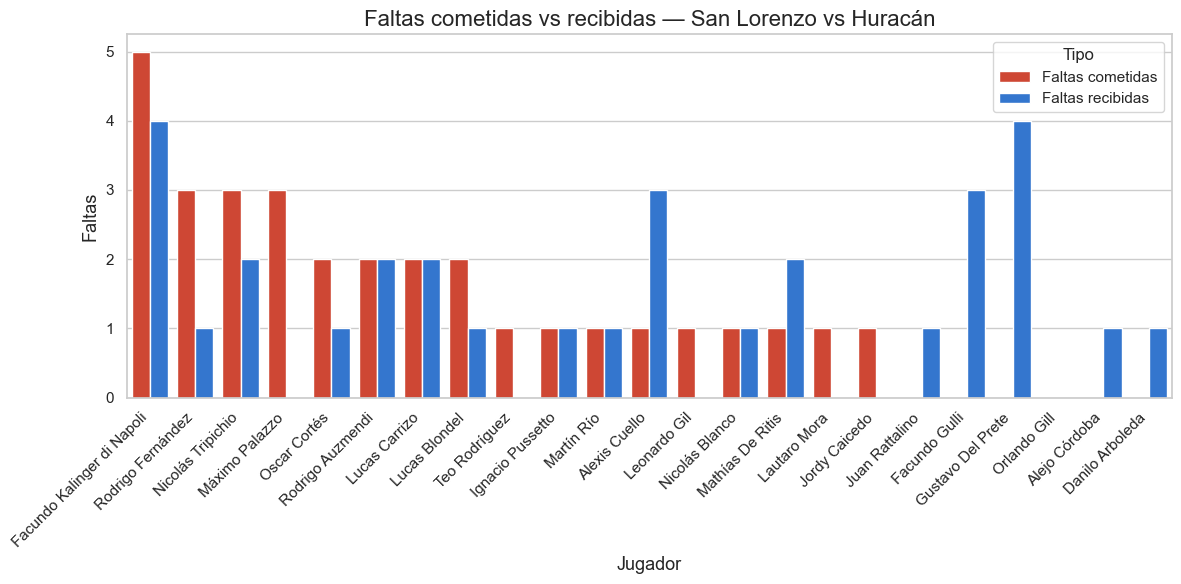

In [42]:
df_disciplina = df_activos[
    (df_activos['Faltas cometidas'] > 0) |
    (df_activos['Faltas recibidas'] > 0) |
    (df_activos['Tarjetas amarillas'] > 0) |
    (df_activos['Tarjetas rojas'] > 0)
].copy()

df_disciplina = df_disciplina.sort_values('Faltas cometidas', ascending=False)

# Faltas cometidas vs recibidas
df_disc_melt = df_disciplina[['Jugador', 'Faltas cometidas', 'Faltas recibidas']].melt(
    id_vars='Jugador',
    var_name='Tipo',
    value_name='Faltas'
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_disc_melt,
    x='Jugador',
    y='Faltas',
    hue='Tipo',
    palette={'Faltas cometidas': '#e8341a', 'Faltas recibidas': '#1a73e8'}
)
plt.title(f'Faltas cometidas vs recibidas — {EQUIPO_LOCAL} vs {EQUIPO_VISITANTE}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/disciplina.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
def perfil_jugador(df: pd.DataFrame, nombre: str) -> None:
    """
    Muestra el perfil completo de un jugador en el partido.
    Compara sus métricas con el promedio de su posición.
    """
    jugador = df[df['Jugador'].str.contains(nombre, case=False, na=False)]

    if jugador.empty:
        print(f"Jugador '{nombre}' no encontrado")
        return

    jugador = jugador.iloc[0]
    posicion = jugador['Posición']
    promedio_pos = df[df['Posición'] == posicion].select_dtypes(include='number').mean()

    metricas = ['Minutos', 'Tiros totales', 'Tiros al arco', 'Goles',
                'Asistencias', 'Entradas ganadas', 'Intercepciones',
                'Faltas cometidas', 'Faltas recibidas', 'Centros']

    metricas_presentes = [m for m in metricas if m in df.columns]

    print(f"\n{'='*50}")
    print(f"PERFIL: {jugador['Jugador']} | {posicion} | {jugador['Minutos']} min")
    print(f"{'='*50}")
    print(f"{'Métrica':<25} {'Valor':>8} {'Prom. posición':>15}")
    print(f"{'-'*50}")
    for m in metricas_presentes:
        if m in jugador.index and m in promedio_pos.index:
            print(f"{m:<25} {jugador[m]:>8.0f} {promedio_pos[m]:>15.1f}")

# Uso
perfil_jugador(df_activos, 'Facundo Kalinger di Napoli')       


PERFIL: Facundo Kalinger di Napoli | Mediocampista central | 77 min
Métrica                      Valor  Prom. posición
--------------------------------------------------
Minutos                         77            75.2
Tiros totales                    1             0.3
Tiros al arco                    0             0.0
Goles                            0             0.0
Asistencias                      1             0.2
Entradas ganadas                 4             1.8
Intercepciones                   0             0.3
Faltas cometidas                 5             2.2
Faltas recibidas                 4             1.8
Centros                          0             2.2
